In [2]:
import boto3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO

BUCKET = "solar-forecast-angelina-2026"
PREFIX = "bhadla/raw/"

s3 = boto3.client("s3")

# List all parquet files under the prefix
response = s3.list_objects_v2(Bucket=BUCKET, Prefix=PREFIX)
parquet_keys = [obj["Key"] for obj in response["Contents"] if obj["Key"].endswith(".parquet")]
print(f"Found {len(parquet_keys)} parquet files")

# Load and concatenate all into one DataFrame
dfs = []
for key in parquet_keys:
    obj = s3.get_object(Bucket=BUCKET, Key=key)
    df = pd.read_parquet(BytesIO(obj["Body"].read()))
    # Extract year/month from path (e.g., bhadla/raw/year=2023/month=05/data.parquet)
    parts = key.split("/")
    df["year"] = int([p for p in parts if p.startswith("year=")][0].split("=")[1])
    df["month"] = int([p for p in parts if p.startswith("month=")][0].split("=")[1])
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True).sort_values("time").reset_index(drop=True)
print(f"Total rows: {len(data)}")
print(f"Date range: {data['time'].min()} to {data['time'].max()}")
data.head()

Found 24 parquet files


Total rows: 17544
Date range: 2023-01-01 00:00:00 to 2024-12-31 23:00:00


,time,shortwave_radiation,direct_radiation,diffuse_radiation,temperature_2m,cloud_cover,wind_speed_10m,relative_humidity_2m,surface_pressure,year,month
0,2023-01-01 00:00:00,0.0,0.0,0.0,11.2,26,8.8,67,998.6,2023,1
1,2023-01-01 01:00:00,0.0,0.0,0.0,10.8,6,10.8,68,998.3,2023,1
2,2023-01-01 02:00:00,0.0,0.0,0.0,9.9,0,11.5,72,997.6,2023,1
3,2023-01-01 03:00:00,0.0,0.0,0.0,9.0,18,10.9,77,997.0,2023,1
4,2023-01-01 04:00:00,0.0,0.0,0.0,8.6,14,10.6,79,996.7,2023,1


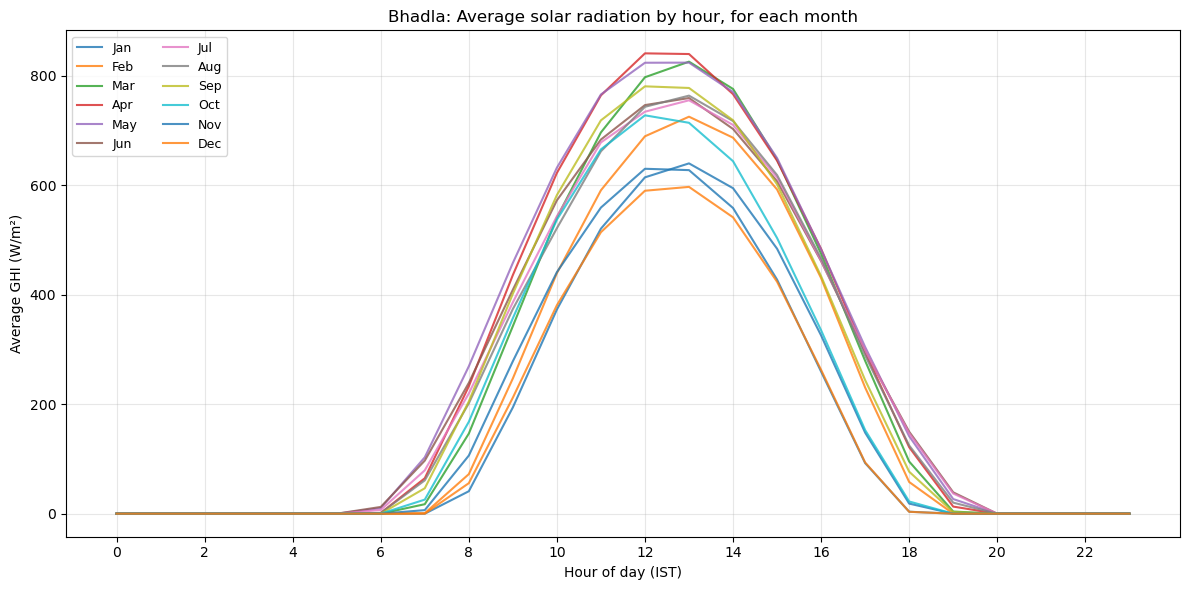

In [3]:
# Compute average radiation by hour-of-day, separated by month for seasonality
data["hour"] = data["time"].dt.hour
data["month_name"] = data["time"].dt.strftime("%b")

hourly_by_month = (
    data.groupby(["month", "hour"])["shortwave_radiation"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
for month_num in sorted(hourly_by_month["month"].unique()):
    subset = hourly_by_month[hourly_by_month["month"] == month_num]
    month_label = pd.Timestamp(2024, month_num, 1).strftime("%b")
    ax.plot(subset["hour"], subset["shortwave_radiation"], label=month_label, alpha=0.8)

ax.set_xlabel("Hour of day (IST)")
ax.set_ylabel("Average GHI (W/m²)")
ax.set_title("Bhadla: Average solar radiation by hour, for each month")
ax.legend(ncol=2, loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

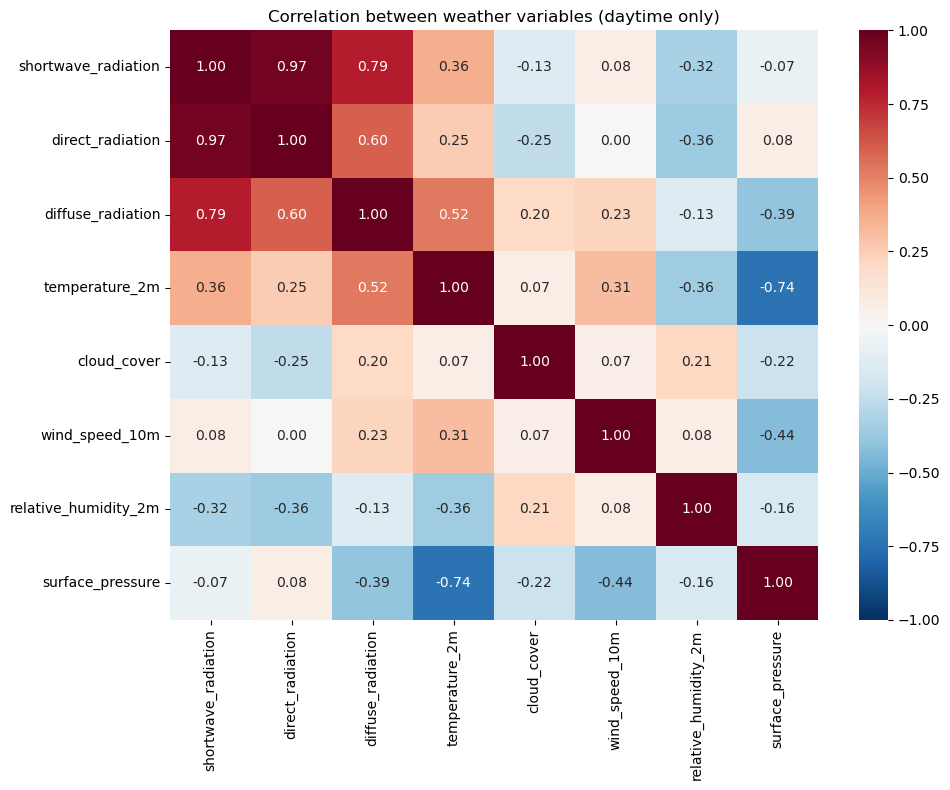

In [4]:
import seaborn as sns

# Only daytime hours, since nighttime correlations are dominated by zeros
daytime = data[data["shortwave_radiation"] > 50].copy()

corr_cols = [
    "shortwave_radiation", "direct_radiation", "diffuse_radiation",
    "temperature_2m", "cloud_cover", "wind_speed_10m",
    "relative_humidity_2m", "surface_pressure"
]
corr = daytime[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation between weather variables (daytime only)")
plt.tight_layout()
plt.show()

In [5]:
import io

# Drop the helper columns we added for analysis
to_save = data.drop(columns=["hour", "month_name"], errors="ignore")

# Write a single consolidated parquet for modeling
buf = io.BytesIO()
to_save.to_parquet(buf, engine="pyarrow", compression="snappy", index=False)
buf.seek(0)

key = "bhadla/curated/bhadla_2023_2024.parquet"
s3.put_object(Bucket=BUCKET, Key=key, Body=buf.getvalue())

print(f"Saved {len(to_save)} rows to s3://{BUCKET}/{key}")
print(f"Size: {buf.tell() / 1024:.1f} KB")

Saved 17544 rows to s3://solar-forecast-angelina-2026/bhadla/curated/bhadla_2023_2024.parquet
Size: 0.0 KB


In [6]:
obj = s3.head_object(Bucket=BUCKET, Key="bhadla/curated/bhadla_2023_2024.parquet")
print(f"Actual size: {obj['ContentLength'] / 1024:.1f} KB")

Actual size: 279.3 KB
